# 📈 Polymarket BTC — XGBoost + Estrategia Production-Ready v4

## Cambios respecto a v2 (y por qué mejoran el Win Rate)

### El diagnóstico

La versión anterior tenía un Win Rate ~25% con exit por stop-loss activo. La causa raíz:

**En mercados binarios de Polymarket, el precio NO converge de forma suave**. El precio del
contrato UP puede caer del 0.60 al 0.40 antes de resolverse en 1.0. Un stop-loss basado en
el precio del bid corta posiciones ganadoras que simplemente estaban en un momento de presión
vendedora. El resultado: 33/44 trades parados en pérdida, muchos de los cuales habrían ganado.

### Las tres correcciones

| # | Cambio | Efecto |
|---|---|---|
| 1 | **Eliminar stop-loss** por precio | Deja vivir posiciones ganadoras hasta resolución |
| 2 | **Filtro `VALUE_EDGE`**: `p_modelo − ask_mercado ≥ umbral` | Solo entrar cuando el modelo ve más valor que el mercado |
| 3 | **Exit único: Model-Flip** cuando el modelo pierde convicción | Sale cuando hay evidencia real de que la tesis cambió |

### Intuición del filtro VALUE_EDGE

Si el modelo dice `P(UP) = 0.70` pero el mercado ya pide `ask = 0.68`, el modelo apenas
aporta información que el mercado no tiene. Si el mercado pide `ask = 0.45` y el modelo
dice 0.70, hay un **desacuerdo estructural de 0.25**: esa es la oportunidad real.

```
VALUE_EDGE_UP = p_up_modelo − up_ask_p_1
```

---

## Garantías de ausencia de leakage

| Punto de decisión | Datos usados | Datos NO usados |
|---|---|---|
| Entrenamiento del modelo | Mercados train (más antiguos) | Val, test, `resolution` |
| Calibración isotónica | Predicciones en val | Test, `resolution` de test |
| `p_up` en snapshot T | Features de la fila T | Cualquier snapshot posterior a T |
| `up_ask_delta` en T | `up_ask` en T − `up_ask` en T−1 (shift dentro del mercado) | Snapshots T+1 en adelante |
| Decisión de entrada en T | `p_up_T`, `ev_T`, `edge_T`, `value_edge_T` | Snapshots posteriores a T |
| Decisión de exit en T' > T | `bid_T'`, `p_up_T'` calculados en T' | `resolution` final |
| `pnl_at_resolution` | `resolution` (solo métrica comparativa post-hoc) | No afecta ninguna decisión |

---
## 1 · Imports y Configuración

In [16]:
# =============================================================================
# 1. IMPORTS Y CONFIGURACIÓN
# =============================================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    roc_auc_score, accuracy_score, brier_score_loss,
    classification_report, roc_curve,
)

# XGBoost (prioridad) / HistGBT (fallback) ------------------------------------
try:
    import xgboost as xgb
    USE_XGB = True
    print(f"XGBoost {xgb.__version__} disponible.")
except ImportError:
    USE_XGB = False
    print("XGBoost no instalado — usando HistGradientBoostingClassifier (sklearn).")
    print("  Para instalar: pip install xgboost")

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.figsize': (13, 4.5),
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})

# =============================================================================
# PARÁMETROS — ajusta aquí
# =============================================================================
CFG = dict(
    DATA_PATH    = '../dataset_with_resolution.csv',
    TRAIN_FRAC   = 0.60,
    VAL_FRAC     = 0.20,

    # Backtest
    STAKE        = 10.0,
    INIT_CAPITAL = 1_000.0,

    # ── Filtros de entrada ─────────────────────────────────────────────────
    ENTRY_LO     = 0.10,    # market_progress mínimo para entrar
    ENTRY_HI     = 0.70,    # market_progress máximo para entrar
    MIN_P        = 0.65,    # subido: pérdidas concentradas en p<0.65 según backtest

    # ── Filtro clave: VALUE_EDGE ───────────────────────────────────────────
    # Con up_ask_p_1 fuera del modelo, value_edge vuelve a ser un discriminador real.
    # El modelo predice desde señales BTC + microestructura, no desde el precio del mercado.
    # Entrar cuando el modelo supera al mercado: value_edge = p_modelo - ask >= umbral.
    VALUE_EDGE   = 0.04,

    # ── Filtros de timing ─────────────────────────────────────────────────
    # Tiempo (segundos) desde el inicio del mercado antes de permitir trades.
    # Evita entrar en la fase de 'price discovery' inicial.
    TRADE_START_SECS = 30,   # No entrar en los primeros N segundos

    # Tiempo (segundos) mínimo que debe quedar para el cierre para permitir trades.
    # Evita entrar demasiado tarde cuando el mercado converge al resultado.
    TRADE_END_SECS   = 30,   # No entrar si quedan <= N segundos

    # ── Exit: solo Model-Flip ─────────────────────────────────────────────
    # Se sale cuando el modelo pierde convicción en la dirección elegida.
    # El stop-loss por precio se elimina: en mercados binarios, el precio
    # oscila antes de converger y un SL de precio corta posiciones ganadoras.
    FLIP_THRESH  = 0.15,    # nivel más bajo más restrictivo (0 = no sale hasta final de mercado)
)

print("Configuración:")
for k, v in CFG.items():
    print(f"  {k:<14} = {v}")

XGBoost 3.2.0 disponible.
Configuración:
  DATA_PATH      = ../dataset_with_resolution.csv
  TRAIN_FRAC     = 0.6
  VAL_FRAC       = 0.2
  STAKE          = 10.0
  INIT_CAPITAL   = 1000.0
  ENTRY_LO       = 0.1
  ENTRY_HI       = 0.7
  MIN_P          = 0.65
  VALUE_EDGE     = 0.04
  TRADE_START_SECS = 30
  TRADE_END_SECS = 30
  FLIP_THRESH    = 0.15


---
## 2 · Carga y Limpieza

In [17]:
# =============================================================================
# 2. CARGA Y LIMPIEZA
# =============================================================================
df = pd.read_csv(CFG['DATA_PATH'], parse_dates=['timestamp'])

if df['timestamp'].dt.tz is None:
    df['timestamp'] = df['timestamp'].dt.tz_localize('UTC')
else:
    df['timestamp'] = df['timestamp'].dt.tz_convert('UTC')

df = df.sort_values(['timestamp', 'market_slug']).reset_index(drop=True)

res_check = df.groupby('market_slug')['resolution'].nunique()
bad = res_check[res_check > 1].index
if len(bad):
    df = df[~df['market_slug'].isin(bad)]
    print(f"Eliminados {len(bad)} mercados con resolución inconsistente.")

num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)
# ⚠️ NO aplicar mediana global aquí — se haría leakage con datos de test.
# La imputación se realiza en Sección 4 usando TRAIN_MED (solo datos de entrenamiento).
df['market_progress'] = df['market_progress'].clip(0.0, 1.0)

print(f"Dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Mercados: {df['market_slug'].nunique():,}")
print(f"Rango: {df['timestamp'].min()}  →  {df['timestamp'].max()}")
print(f"Resoluciones: {df['resolution'].value_counts().to_dict()}")

Dataset: 84,070 filas × 66 columnas
Mercados: 875
Rango: 2026-03-19 16:15:55.759706+00:00  →  2026-03-22 17:05:13.910494+00:00
Resoluciones: {'down': 42250, 'up': 41820}


In [18]:
# =============================================================================
# 2b. CÓMPUTO DE FEATURES DE TIMING (por mercado)
# =============================================================================
# Para cada snapshot calculamos:
#   seconds_from_open : segundos transcurridos desde el primer snapshot del mercado
#   seconds_to_close  : segundos restantes hasta el último snapshot (proxy del cierre)
#   market_duration_s : duración total estimada del mercado (en segundos)
#
# Nota: usamos primer/último snapshot como proxy del inicio/cierre real.
# En producción estos valores vendrán del campo market_end_date de la API.

_times = (
    df.groupby('market_slug')['timestamp']
    .agg(market_open='min', market_close='max')
    .reset_index()
)
df = df.merge(_times, on='market_slug', how='left')

df['market_duration_s'] = (
    df['market_close'] - df['market_open']
).dt.total_seconds().clip(lower=1)   # evita división por cero

df['seconds_from_open'] = (
    df['timestamp'] - df['market_open']
).dt.total_seconds().clip(lower=0)

df['seconds_to_close'] = (
    df['market_close'] - df['timestamp']
).dt.total_seconds().clip(lower=0)

print(f"Timing features añadidos. Duración media de mercado: "
      f"{df['market_duration_s'].mean():.1f} s  "
      f"(mediana: {df['market_duration_s'].median():.1f} s)")
print(df[['seconds_from_open','seconds_to_close','market_duration_s']].describe().round(1).to_string())


Timing features añadidos. Duración media de mercado: 296.8 s  (mediana: 296.8 s)
       seconds_from_open  seconds_to_close  market_duration_s
count            84070.0           84070.0            84070.0
mean               147.9             148.9              296.8
std                 86.3              86.3                3.1
min                  0.0               0.0               12.8
25%                 73.6              74.3              295.8
50%                147.7             149.0              296.8
75%                222.3             223.5              297.9
max                300.3             300.3              300.3


---
## 3 · Feature Engineering

**18 features, 3 fuentes de datos.**

Solo 2 features requieren `shift(1)` dentro del mercado (`up_ask_delta`, `down_ask_delta`).
El resto son columnas directas del CSV o ratios calculados en tiempo T — sin estado adicional en producción.

| Grupo | Features | Fuente |
|---|---|---|
| BTC momentum | `ret_1m/3m/5m/10m`, `ema_cross`, `btc_return_since_open` | Feed BTC |
| BTC vol/vol | `volatility_5m`, `vol_ratio`, `volume_1m` | Feed BTC |
| Polymarket book | `mkt_premium`, `spread_up`, `spread_down`, `up_book_imbalance`, `down_book_imbalance` | API Polymarket |
| Polymarket momentum | `up_ask_delta`, `down_ask_delta` | API Polymarket |
| Binance | `binance_imbalance` | API Binance |
| Estado | `market_progress` | API Polymarket |

**Auditoría look-ahead:**
- `ema_cross` = `ema_3[T] > ema_12[T]` — ambas columnas son valores del snapshot actual ✓
- `vol_ratio` = `volatility_3m[T] / volatility_5m[T]` — mismo snapshot ✓
- `spread_up/down` = `ask[T] − bid[T]` — mismo snapshot ✓
- `up_book_imbalance` = `(bid_s_1[T] − ask_s_1[T]) / sum` — mismo snapshot ✓
- `binance_imbalance` = `(bid_vol[T] − ask_vol[T]) / sum` — mismo snapshot ✓
- `up_ask_delta` = `up_ask[T] − up_ask[T−1]` via `groupby.shift(1)` — solo snapshot anterior ✓


In [19]:
# =============================================================================
# 3. FEATURE ENGINEERING
# =============================================================================
fe = df.copy()

# ── BTC: tendencia y régimen ──────────────────────────────────────────────────
fe['ema_cross']            = (fe['ema_3'] > fe['ema_12']).astype(int)  # 1=alcista
fe['vol_ratio']            = fe['volatility_3m'] / (fe['volatility_5m'] + 1e-9)  # >1=vol expand.

# ── Polymarket: precio relativo y spread ─────────────────────────────────────
fe['mkt_premium']          = fe['up_ask_p_1'] - fe['down_ask_p_1']          # sesgo direccional
fe['spread_up']            = fe['up_ask_p_1']   - fe['up_bid_p_1']          # liquidez UP
fe['spread_down']          = fe['down_ask_p_1'] - fe['down_bid_p_1']        # liquidez DOWN

# ── Polymarket: presión de libro de órdenes L1 ───────────────────────────────
# >0 = más tamaño en bid (presión compradora), <0 = más en ask (presión vendedora)
fe['up_book_imbalance']    = (
    (fe['up_bid_s_1']   - fe['up_ask_s_1']) /
    (fe['up_bid_s_1']   + fe['up_ask_s_1']   + 1e-9)
)
fe['down_book_imbalance']  = (
    (fe['down_bid_s_1'] - fe['down_ask_s_1']) /
    (fe['down_bid_s_1'] + fe['down_ask_s_1'] + 1e-9)
)

# ── Polymarket: momentum del precio del mercado (sin look-ahead) ─────────────
# shift(1) dentro del mismo mercado → solo usa el snapshot inmediatamente anterior
fe = fe.sort_values(['market_slug', 'timestamp'])
fe['up_ask_delta']         = fe['up_ask_p_1']   - fe.groupby('market_slug')['up_ask_p_1'].shift(1)
fe['down_ask_delta']       = fe['down_ask_p_1'] - fe.groupby('market_slug')['down_ask_p_1'].shift(1)
fe = fe.sort_values(['timestamp', 'market_slug']).reset_index(drop=True)
fe[['up_ask_delta', 'down_ask_delta']] = fe[['up_ask_delta', 'down_ask_delta']].fillna(0)

# ── Binance: presión direccional del order book ───────────────────────────────
fe['binance_imbalance']    = (
    (fe['bid_volume_10'] - fe['ask_volume_10']) /
    (fe['bid_volume_10'] + fe['ask_volume_10'] + 1e-9)
)

# ── Flow ─────────────────────────────────────────────────────────────────────
fe['buy_sell_ratio']       = fe['buy_volume_last200'] / (fe['sell_volume_last200'] + 1e-9)

# ── Target ───────────────────────────────────────────────────────────────────
fe['y'] = (fe['resolution'].str.lower() == 'up').astype(int)

# ── Feature set v4 (18 features) ─────────────────────────────────────────────
FEATURES = [
    # BTC momentum (multi-timeframe)
    'ret_1m', 'ret_3m', 'ret_5m', 'ret_10m',
    'ema_cross',
    'btc_return_since_open',
    # BTC volatilidad y volumen
    'volatility_5m', 'vol_ratio', 'volume_1m',
    # Polymarket book — precio relativo y liquidez
    'mkt_premium', 'spread_up', 'spread_down',
    # Polymarket book — presión L1
    'up_book_imbalance', 'down_book_imbalance',
    # Polymarket book — momentum del precio
    'up_ask_delta', 'down_ask_delta',
    # Binance
    'binance_imbalance',
    # Flow y estado
    'buy_sell_ratio', 'market_progress',
]
FEATURES = [f for f in FEATURES if f in fe.columns]
print(f"Features v4: {len(FEATURES)}")
missing = [f for f in [
    'ret_1m','ret_3m','ret_5m','ret_10m','ema_cross','btc_return_since_open',
    'volatility_5m','vol_ratio','volume_1m','mkt_premium','spread_up','spread_down',
    'up_book_imbalance','down_book_imbalance','up_ask_delta','down_ask_delta',
    'binance_imbalance','buy_sell_ratio','market_progress',
] if f not in fe.columns]
if missing:
    print(f"  ⚠️  Columnas no encontradas en CSV: {missing}")
else:
    print("  ✓ Todas las columnas presentes en el dataset")
print(fe[FEATURES].describe().round(3).to_string())


Features v4: 19
  ✓ Todas las columnas presentes en el dataset
          ret_1m     ret_3m     ret_5m    ret_10m  ema_cross  btc_return_since_open  volatility_5m  vol_ratio  volume_1m  mkt_premium  spread_up  spread_down  up_book_imbalance  down_book_imbalance  up_ask_delta  down_ask_delta  binance_imbalance  buy_sell_ratio  market_progress
count  84070.000  84070.000  84070.000  84070.000  84070.000              84070.000      84069.000  84069.000  84069.000    78266.000  78264.000    78261.000          78264.000            78261.000     84070.000       84070.000          84070.000    8.406900e+04        84070.000
mean       0.001     -0.000     -0.000     -0.000      0.494                 -0.000          0.000      0.935     10.769        0.003      0.013        0.013             -0.008                0.008        -0.000          -0.000             -0.024    1.100993e+07            0.497
std        0.349      0.001      0.001      0.002      0.500                  0.001          0.00

---
## 4 · Split Temporal y Matrices

In [20]:
# =============================================================================
# 4. SPLIT TEMPORAL POR MERCADO
# =============================================================================
market_order = (
    fe.groupby('market_slug')['timestamp'].min()
      .sort_values().index.tolist()
)
N = len(market_order)
n_train = int(N * CFG['TRAIN_FRAC'])
n_val   = int(N * CFG['VAL_FRAC'])

train_m = market_order[:n_train]
val_m   = market_order[n_train : n_train + n_val]
test_m  = market_order[n_train + n_val :]

tr = fe[fe['market_slug'].isin(train_m)].copy()
va = fe[fe['market_slug'].isin(val_m)].copy()
te = fe[fe['market_slug'].isin(test_m)].copy()

assert tr['timestamp'].max() < va['timestamp'].min(), "LEAKAGE train/val"
assert va['timestamp'].max() < te['timestamp'].min(), "LEAKAGE val/test"
print("Sin leakage temporal confirmado.")

TRAIN_MED = pd.DataFrame(tr[FEATURES].values, columns=FEATURES).median()

def to_matrix(df_split):
    return (
        pd.DataFrame(df_split[FEATURES].values, columns=FEATURES)
        .replace([np.inf, -np.inf], np.nan)
        .fillna(TRAIN_MED)
        .values
    )

X_tr = to_matrix(tr); y_tr = tr['y'].values
X_va = to_matrix(va); y_va = va['y'].values
X_te = to_matrix(te); y_te = te['y'].values

print(f"\n{'Split':<12} {'Mercados':>9} {'Filas':>8} {'UP%':>6}")
print("-" * 38)
for name, split, y in [('Train', tr, y_tr), ('Validación', va, y_va), ('Test', te, y_te)]:
    print(f"{name:<12} {split['market_slug'].nunique():>9,} {len(split):>8,} {y.mean():>6.1%}")

Sin leakage temporal confirmado.

Split         Mercados    Filas    UP%
--------------------------------------
Train              525   50,432  50.0%
Validación         175   16,852  50.0%
Test               175   16,786  48.6%


---
## 5 · Entrenamiento XGBoost

Mejor iteración: 206


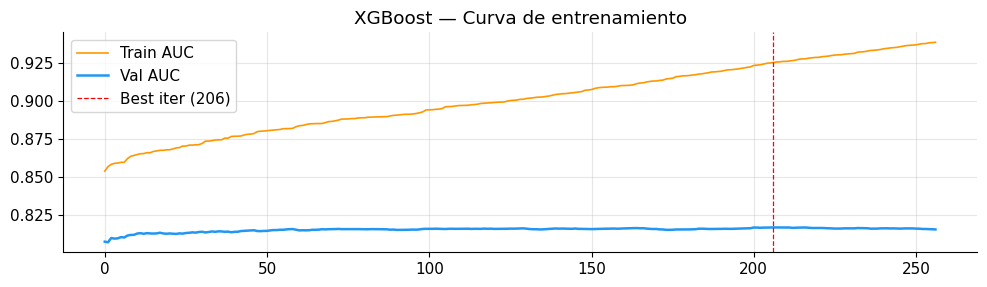


Set              AUC   Accuracy    Brier
----------------------------------------
Validación    0.8179     0.7231   0.1704
Test          0.8047     0.7270   0.1817

Classification report (test):
              precision    recall  f1-score   support

        DOWN       0.74      0.72      0.73      8623
          UP       0.71      0.73      0.72      8163

    accuracy                           0.73     16786
   macro avg       0.73      0.73      0.73     16786
weighted avg       0.73      0.73      0.73     16786



In [21]:
# =============================================================================
# 5. ENTRENAMIENTO
# =============================================================================
if USE_XGB:
    dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=FEATURES)
    dval   = xgb.DMatrix(X_va, label=y_va, feature_names=FEATURES)

    xgb_params = {
        'objective'        : 'binary:logistic',
        'eval_metric'      : 'auc',
        'eta'              : 0.03,
        'max_depth'        : 5,
        'min_child_weight' : 20,
        'subsample'        : 0.80,
        'colsample_bytree' : 0.80,
        'alpha'            : 0.1,
        'lambda'           : 1.0,
        'seed'             : SEED,
    }

    evals_result = {}
    booster = xgb.train(
        xgb_params, dtrain,
        num_boost_round       = 800,
        evals                 = [(dtrain, 'train'), (dval, 'val')],
        early_stopping_rounds = 50,
        evals_result          = evals_result,
        verbose_eval          = False,
    )
    print(f"Mejor iteración: {booster.best_iteration}")

    class XGBModel:
        def __init__(self, bst):
            self.bst = bst
        def predict_proba(self, X):
            dm = xgb.DMatrix(X, feature_names=FEATURES)
            p  = self.bst.predict(dm)
            return np.column_stack([1 - p, p])
        @property
        def feature_importances_(self):
            scores = self.bst.get_score(importance_type='gain')
            return np.array([scores.get(f, 0.0) for f in FEATURES])

    raw_model = XGBModel(booster)

    # Curva de entrenamiento
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(evals_result['train']['auc'], lw=1.2, label='Train AUC', color='#FF9800')
    ax.plot(evals_result['val']['auc'],   lw=1.8, label='Val AUC',   color='#2196F3')
    ax.axvline(booster.best_iteration, ls='--', color='red', lw=0.9,
               label=f'Best iter ({booster.best_iteration})')
    ax.set_title('XGBoost — Curva de entrenamiento'); ax.legend()
    plt.tight_layout(); plt.show()

else:
    raw_model = HistGradientBoostingClassifier(
        max_iter=600, learning_rate=0.03, max_depth=5,
        min_samples_leaf=20, l2_regularization=0.1, random_state=SEED,
    )
    raw_model.fit(X_tr, y_tr)
    print("HistGradientBoostingClassifier entrenado (fallback).")

# Calibración isotónica — solo sobre validación
p_va_raw = raw_model.predict_proba(X_va)[:, 1]
iso_cal  = IsotonicRegression(out_of_bounds='clip')
iso_cal.fit(p_va_raw, y_va)

class CalibratedModel:
    def __init__(self, base, cal):
        self.base = base; self.cal = cal
    def predict_proba(self, X):
        p_raw = self.base.predict_proba(X)[:, 1]
        p_cal = self.cal.transform(p_raw)
        return np.column_stack([1 - p_cal, p_cal])

MODEL = CalibratedModel(raw_model, iso_cal)

p_va = MODEL.predict_proba(X_va)[:, 1]
p_te = MODEL.predict_proba(X_te)[:, 1]

print(f"\n{'Set':<12} {'AUC':>7} {'Accuracy':>10} {'Brier':>8}")
print("-" * 40)
for name, p, y in [('Validación', p_va, y_va), ('Test', p_te, y_te)]:
    auc = roc_auc_score(y, p)
    acc = accuracy_score(y, (p >= 0.5).astype(int))
    bs  = brier_score_loss(y, p)
    print(f"{name:<12} {auc:>7.4f} {acc:>10.4f} {bs:>8.4f}")

print("\nClassification report (test):")
print(classification_report(y_te, (p_te >= 0.5).astype(int), target_names=['DOWN','UP']))

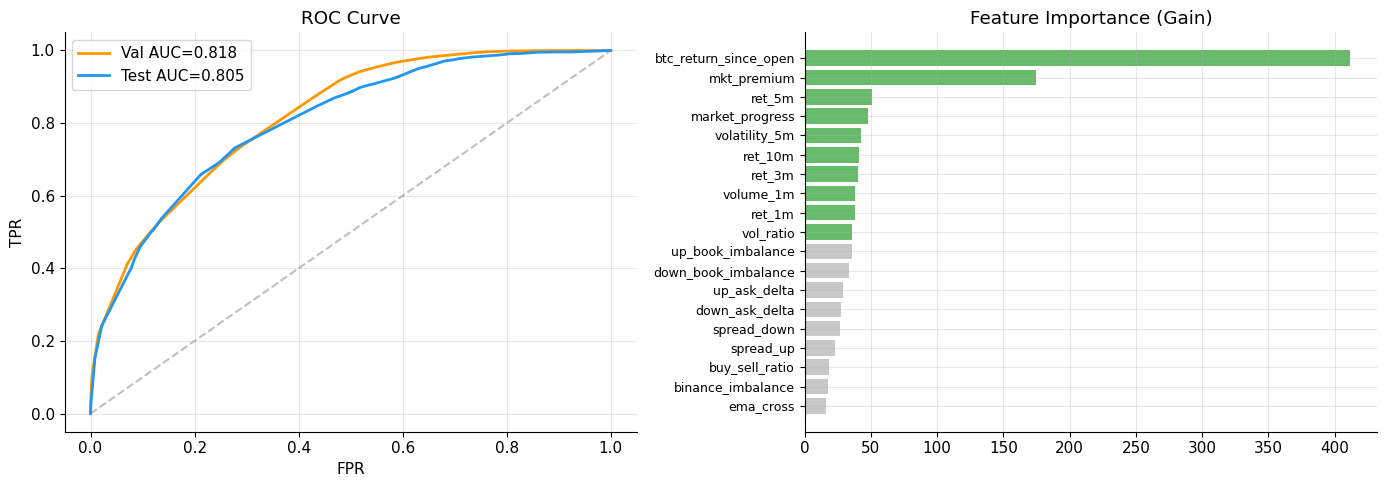

In [22]:
# ROC y Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
for (name, p, y), c in zip(
    [('Val', p_va, y_va), ('Test', p_te, y_te)],
    ['#FF9800', '#2196F3']
):
    fpr, tpr, _ = roc_curve(y, p)
    axes[0].plot(fpr, tpr, color=c, lw=2, label=f"{name} AUC={roc_auc_score(y,p):.3f}")
axes[0].plot([0,1],[0,1],'--',color='gray',alpha=0.5)
axes[0].set(title='ROC Curve', xlabel='FPR', ylabel='TPR')
axes[0].legend()

# Feature importance
if hasattr(raw_model, 'feature_importances_'):
    fi = pd.Series(raw_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    colors_fi = ['#4CAF50' if v >= fi.median() else '#BDBDBD' for v in fi.values]
    axes[1].barh(range(len(fi)), fi.values, color=colors_fi, alpha=0.85)
    axes[1].set_yticks(range(len(fi)))
    axes[1].set_yticklabels(fi.index, fontsize=9)
    axes[1].set_title('Feature Importance (Gain)')

plt.tight_layout()
plt.show()

---
## 6 · Scoring, EV y VALUE_EDGE

Distribución del VALUE_EDGE (test set):
       value_edge_up  value_edge_down
count     16271.0000       16112.0000
mean         -0.0048          -0.0027
std           0.0819           0.0846
min          -0.3770          -0.3479
25%          -0.0570          -0.0539
50%          -0.0086           0.0030
75%           0.0435           0.0486
max           0.5714           0.4961


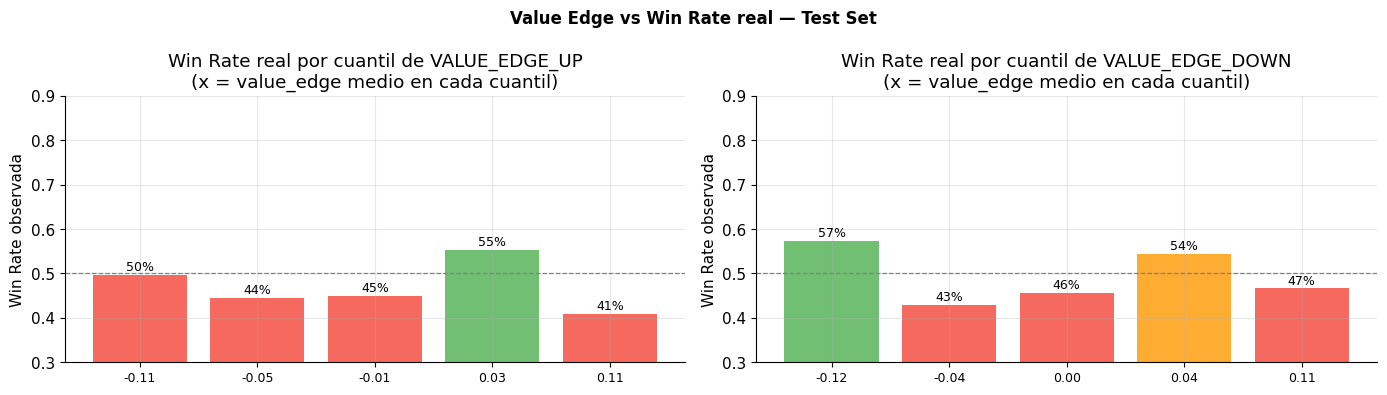

In [23]:
# =============================================================================
# 6. SCORING, EV Y VALUE_EDGE
# =============================================================================
# Sin leakage: predict_proba se aplica por fila usando únicamente las features
# de ese snapshot. Cada fila es independiente del resto en la inferencia.

X_all    = to_matrix(fe)
fe['p_up']   = MODEL.predict_proba(X_all)[:, 1]
fe['p_down'] = 1.0 - fe['p_up']

# EV = P(ganar) × win_net + P(perder) × loss_net
fe['ev_up']   = fe['p_up']   * fe['up_win_net']   + fe['p_down'] * fe['up_loss_net']
fe['ev_down'] = fe['p_down'] * fe['down_win_net'] + fe['p_up']   * fe['down_loss_net']

# Edge = P(modelo) − break_even del contrato
fe['edge_up']  = fe['p_up']   - fe['up_break_even']
fe['edge_down']= fe['p_down'] - fe['down_break_even']

# VALUE_EDGE = P(modelo) − precio_ask_mercado
# Mide cuánto más confiado está el modelo que el mercado.
# Solo tiene sentido entrar cuando el modelo ve algo que el mercado no ha descontado.
fe['value_edge_up']   = fe['p_up']   - fe['up_ask_p_1']
fe['value_edge_down'] = fe['p_down'] - fe['down_ask_p_1']

test_fe = fe[fe['market_slug'].isin(test_m)].copy()

# Análisis del value_edge en el test set
print("Distribución del VALUE_EDGE (test set):")
print(test_fe[['value_edge_up','value_edge_down']].describe().round(4).to_string())

# Visualización: WR observada por cuartil de value_edge
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, title in [
    (axes[0], 'value_edge_up',   'VALUE_EDGE_UP'),
    (axes[1], 'value_edge_down', 'VALUE_EDGE_DOWN'),
]:
    test_fe['_q'] = pd.qcut(test_fe[col], q=5, labels=False, duplicates='drop')
    grp = test_fe.groupby('_q', observed=True)
    means = grp['y'].mean() if col == 'value_edge_up' else 1 - grp['y'].mean()
    edges = grp[col].mean()
    bars = ax.bar(range(len(means)), means.values, alpha=0.8,
                  color=['#4CAF50' if v > 0.55 else '#FF9800' if v > 0.50 else '#F44336'
                         for v in means.values])
    ax.axhline(0.5, ls='--', color='gray', lw=0.9)
    ax.set_xticks(range(len(means)))
    ax.set_xticklabels([f'{v:.2f}' for v in edges.values], fontsize=9)
    ax.set_title(f'Win Rate real por cuantil de {title}\n(x = value_edge medio en cada cuantil)')
    ax.set_ylabel('Win Rate observada'); ax.set_ylim(0.3, 0.9)
    for bar, v in zip(bars, means.values):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.0%}', ha='center', fontsize=9)

plt.suptitle('Value Edge vs Win Rate real — Test Set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7 · Estrategia de Entrada (Production-Ready)

### Reglas de entrada — 2 filtros

El modelo predice desde señales BTC + microestructura (sin `up_ask_p_1`).
Entrar cuando el modelo supera al mercado y tiene convicción mínima.

```
value_edge = p_modelo - ask_mercado

Condición de entrada (dirección UP):
  p_up        >= MIN_P       →  convicción mínima del modelo
  value_edge  >= VALUE_EDGE  →  modelo supera al mercado
```

En producción:
```python
value_edge = p_model - market_ask
if p_model >= MIN_P and value_edge >= VALUE_EDGE:
    enter(direction)
```


In [24]:
# =============================================================================
# 7. ESTRATEGIA DE ENTRADA — PRODUCCIÓN-CORRECTA
# =============================================================================

def find_entry(market_snaps, cfg):
    """
    Encuentra el punto de entrada para UN mercado.
    Procesamiento en orden de timestamp: solo usa datos del snapshot actual.
    2 filtros: MIN_P + VALUE_EDGE.
    """
    lo, hi = cfg['ENTRY_LO'], cfg['ENTRY_HI']
    t_start = cfg.get('TRADE_START_SECS', 0)    # mín. segundos desde inicio
    t_end   = cfg.get('TRADE_END_SECS',   0)    # mín. segundos hasta cierre

    window = (
        market_snaps[
            (market_snaps['market_progress']  >= lo) &
            (market_snaps['market_progress']  <= hi) &
            (market_snaps['seconds_from_open'] >= t_start) &
            (market_snaps['seconds_to_close']  >  t_end)
        ]
        .sort_values('timestamp')
        .reset_index(drop=True)
    )

    if window.empty:
        return None, None

    for _, row in window.iterrows():
        candidates = []
        for direction, p_col, ask_col in [
            ('UP',   'p_up',   'up_ask_p_1'),
            ('DOWN', 'p_down', 'down_ask_p_1'),
        ]:
            ve = float(row[p_col]) - float(row[ask_col])
            if (
                float(row[p_col]) >= cfg['MIN_P'] and
                ve                >= cfg['VALUE_EDGE']
            ):
                candidates.append((direction, ve))

        if candidates:
            best_dir = max(candidates, key=lambda x: x[1])[0]
            return row, best_dir

    return None, None


# Sanity check: orden cronológico en todos los mercados del test set
for mkt, grp in test_fe.groupby('market_slug'):
    ts = grp.sort_values('timestamp')['timestamp'].values
    assert np.all(ts[:-1] <= ts[1:]), f"Timestamps no monotónicos en {mkt}"
print("Orden cronológico verificado en todos los mercados del test set.")

# Distribución de entradas
entry_stats = []
for mkt, grp in test_fe.groupby('market_slug'):
    snaps = grp.sort_values('timestamp').reset_index(drop=True)
    row, direction = find_entry(snaps, CFG)
    if row is not None:
        p_col  = f'p_{direction.lower()}'
        ask_col = 'up_ask_p_1' if direction == 'UP' else 'down_ask_p_1'
        entry_stats.append({
            'market'     : mkt,
            'direction'  : direction,
            'timestamp'  : row['timestamp'],
            'progress'   : row['market_progress'],
            'p'          : row[p_col],
            'value_edge' : float(row[p_col]) - float(row[ask_col]),
            'ask'        : row[ask_col],
        })

df_entries = pd.DataFrame(entry_stats)
print(f"\nMercados con señal: {len(df_entries)} / {test_fe['market_slug'].nunique()}")
if not df_entries.empty:
    print(f"Dirección: {df_entries['direction'].value_counts().to_dict()}")
    print(f"\nDistribución de entradas:")
    print(df_entries[['direction','progress','p','value_edge','ask']].describe().round(3).to_string())


Orden cronológico verificado en todos los mercados del test set.

Mercados con señal: 148 / 175
Dirección: {'DOWN': 85, 'UP': 63}

Distribución de entradas:
       progress        p  value_edge      ask
count   148.000  148.000     148.000  148.000
mean      0.257    0.781       0.083    0.697
std       0.155    0.067       0.036    0.078
min       0.100    0.690       0.040    0.500
25%       0.137    0.743       0.056    0.650
50%       0.203    0.776       0.073    0.680
75%       0.394    0.800       0.103    0.730
max       0.690    0.975       0.213    0.930


---
## 8 · Motor de Backtest con Exit

**Una única regla de exit: Model-Flip.**

El stop-loss por precio se elimina porque en mercados binarios de Polymarket:
- El precio de la share NO converge suavemente — oscila hasta resolución
- Un SL del 15% sobre el bid dispara el 75% de las veces, cortando ganadores
- La señal real de que la tesis cambió es el modelo, no el precio

Cuando `P(dirección)_t < FLIP_THRESH`, el modelo ha visto nuevos datos (BTC, order book)
que contradicen la tesis original → es el momento de salir.

In [25]:
# =============================================================================
# 8. MOTOR DE BACKTEST
# =============================================================================

def early_exit_pnl(stake, entry_ask, exit_bid):
    """PnL de salida anticipada: stake × (exit_bid / entry_ask − 1)."""
    return stake * (exit_bid / entry_ask - 1.0)


def run_backtest(snapshot_df, cfg):
    """
    Backtest producción-correcto. Un trade por mercado.

    Garantías:
    - Entrada: find_entry procesa en orden de timestamp, entra en el primero
      que cumple criterios (sin look-ahead).
    - Exit: solo evalúa snapshots con timestamp > entry_timestamp.
    - 'resolution' se usa solo en pnl_at_resolution (referencia post-hoc).
    """
    FLIP  = cfg['FLIP_THRESH']
    STAKE = cfg['STAKE']
    trades = []

    for mkt, grp in snapshot_df.groupby('market_slug'):
        snaps = grp.sort_values('timestamp').reset_index(drop=True)

        # 1. Encontrar entrada
        entry_row, direction = find_entry(snaps, cfg)
        if entry_row is None:
            continue

        entry_ts  = entry_row['timestamp']
        entry_ask = (
            entry_row['up_ask_p_1']   if direction == 'UP'
            else entry_row['down_ask_p_1']
        )
        if entry_ask <= 0 or np.isnan(entry_ask):
            continue

        # Referencia: resultado en resolución (solo estadística comparativa)
        resolution = snaps['resolution'].iloc[0]
        actual_up  = (resolution.lower() == 'up')
        won_at_res = (actual_up if direction == 'UP' else not actual_up)
        win_net    = entry_row['up_win_net']  if direction == 'UP' else entry_row['down_win_net']
        loss_net   = entry_row['up_loss_net'] if direction == 'UP' else entry_row['down_loss_net']
        pnl_at_res = win_net if won_at_res else loss_net

        # 2. Evaluar exit en snapshots POSTERIORES a la entrada
        exit_type  = 'RESOLUTION'
        exit_pnl   = pnl_at_res
        exit_prog  = snaps['market_progress'].iloc[-1]
        exit_bid   = np.nan

        future = snaps[
            snaps['timestamp'] > entry_ts   # filtro por timestamp real
        ].reset_index(drop=True)

        for _, snap in future.iterrows():
            cur_bid = snap['up_bid_p_1']   if direction == 'UP' else snap['down_bid_p_1']
            cur_p   = snap['p_up']         if direction == 'UP' else snap['p_down']

            if np.isnan(cur_bid) or cur_bid <= 0:
                continue

            # MODEL FLIP: el modelo pierde convicción en la dirección elegida
            if cur_p < FLIP:
                ep         = early_exit_pnl(STAKE, entry_ask, cur_bid)
                exit_type  = 'MODEL_FLIP'
                exit_pnl   = ep
                exit_prog  = snap['market_progress']
                exit_bid   = cur_bid
                break

        trades.append({
            'timestamp'        : entry_ts,
            'seconds_from_open': float(entry_row.get('seconds_from_open', np.nan)),
            'seconds_to_close' : float(entry_row.get('seconds_to_close',  np.nan)),
            'market_duration_s': float(entry_row.get('market_duration_s', np.nan)),
            'market'           : mkt,
            'direction'        : direction,
            'resolution'       : resolution,
            'won_at_resolution': won_at_res,
            'entry_progress'   : entry_row['market_progress'],
            'entry_ask'        : entry_ask,
            'p_entry'          : entry_row[f'p_{direction.lower()}'],
            'ev_entry'         : entry_row[f'ev_{direction.lower()}'],
            'value_edge_entry' : entry_row[f'value_edge_{direction.lower()}'],
            'exit_type'        : exit_type,
            'exit_progress'    : exit_prog,
            'exit_bid'         : exit_bid,
            'pnl'              : exit_pnl,
            'pnl_at_resolution': pnl_at_res,
        })

    if not trades:
        return pd.DataFrame(), pd.Series(dtype=float)

    tdf = (
        pd.DataFrame(trades)
        .sort_values('timestamp')
        .reset_index(drop=True)
    )
    tdf['cumulative_pnl'] = tdf['pnl'].cumsum()
    tdf['equity']         = cfg['INIT_CAPITAL'] + tdf['cumulative_pnl']

    equity_s = pd.concat([
        pd.Series([cfg['INIT_CAPITAL']], index=[tdf['timestamp'].iloc[0]]),
        tdf.set_index('timestamp')['equity'],
    ])
    return tdf, equity_s


print("Motor de backtest definido.")

Motor de backtest definido.


---
## 9 · Resultados

In [26]:
# =============================================================================
# 9. EJECUTAR BACKTEST — CON EXIT vs SIN EXIT
# =============================================================================

# Con exit (CFG actual)
trade_log, equity = run_backtest(test_fe, CFG)

# Sin exit: desactiva el model-flip para medir su efecto neto
cfg_no_exit = {**CFG, 'FLIP_THRESH': 0.0}   # nunca se activa
trade_log_no, equity_no = run_backtest(test_fe, cfg_no_exit)


def print_stats(tdf, eq_s, label, cfg):
    if tdf.empty:
        print(f"{label}: sin trades."); return {}
    n    = len(tdf)
    nw   = (tdf['pnl'] > 0).sum()
    wr   = nw / n
    gp   = tdf[tdf['pnl'] > 0]['pnl'].sum()
    gl   = tdf[tdf['pnl'] < 0]['pnl'].abs().sum()
    pf   = gp / (gl + 1e-9)
    total = tdf['pnl'].sum()
    roi   = total / cfg['INIT_CAPITAL']
    eq    = eq_s.values; rm = np.maximum.accumulate(eq)
    mdd   = ((eq - rm) / rm).min()
    pa    = tdf['pnl'].values
    sharpe= pa.mean() / (pa.std() + 1e-9) * np.sqrt(n)

    print(f"\n{'═'*50}")
    print(f"  {label}")
    print(f"{'═'*50}")
    print(f"  N trades         : {n}")
    print(f"  Win Rate         : {wr:.1%}  ({nw}W / {n-nw}L)")
    print(f"  Profit Factor    : {pf:.3f}")
    print(f"  PnL Total        : {total:+.2f} USDC")
    print(f"  ROI              : {roi:.2%}")
    print(f"  PnL medio/trade  : {pa.mean():.3f} USDC")
    print(f"  Peor trade       : {pa.min():.3f} USDC")
    print(f"  Mejor trade      : {pa.max():.3f} USDC")
    print(f"  Max Drawdown     : {mdd:.2%}")
    print(f"  Sharpe (simple)  : {sharpe:.3f}")
    print(f"  Equity final     : {eq_s.iloc[-1]:.2f} USDC")
    if 'exit_type' in tdf.columns:
        print("\n  Por tipo de exit:")
        print(tdf.groupby('exit_type').agg(
            n=('pnl','count'), pnl=('pnl','sum'), media=('pnl','mean'), wr=('pnl', lambda x:(x>0).mean())
        ).round(3).to_string())
    return dict(n=n, wr=wr, pf=pf, total=total, roi=roi, mdd=mdd, sharpe=sharpe)


stats = print_stats(trade_log,    equity,    'CON Model-Flip exit', CFG)
stats_no = print_stats(trade_log_no, equity_no, 'SIN exit (hold)',  CFG)

if not trade_log.empty and not trade_log_no.empty:
    delta = trade_log['pnl'].sum() - trade_log_no['pnl'].sum()
    print(f"\n  ΔPnL (exit − hold): {delta:+.2f} USDC")

print("\nDetalle de trades:")
print(trade_log[[
    'market','direction','resolution','entry_progress',
    'p_entry','value_edge_entry','exit_type','exit_progress','pnl','pnl_at_resolution'
]].to_string(index=False))


══════════════════════════════════════════════════
  CON Model-Flip exit
══════════════════════════════════════════════════
  N trades         : 148
  Win Rate         : 66.9%  (99W / 49L)
  Profit Factor    : 1.042
  PnL Total        : +17.12 USDC
  ROI              : 1.71%
  PnL medio/trade  : 0.116 USDC
  Peor trade       : -10.010 USDC
  Mejor trade      : 8.858 USDC
  Max Drawdown     : -5.83%
  Sharpe (simple)  : 0.230
  Equity final     : 1017.12 USDC

  Por tipo de exit:
              n      pnl  media     wr
exit_type                             
MODEL_FLIP   45 -369.049 -8.201  0.000
RESOLUTION  103  386.170  3.749  0.961

══════════════════════════════════════════════════
  SIN exit (hold)
══════════════════════════════════════════════════
  N trades         : 148
  Win Rate         : 70.9%  (105W / 43L)
  Profit Factor    : 1.055
  PnL Total        : +23.79 USDC
  ROI              : 2.38%
  PnL medio/trade  : 0.161 USDC
  Peor trade       : -10.010 USDC
  Mejor trade      

---
## 9.5 · Análisis de Timing de Trades

Distribución de **cuándo** entra el modelo: tiempo desde apertura del mercado
y tiempo restante hasta el cierre. Permite calibrar `TRADE_START_SECS` y `TRADE_END_SECS`.


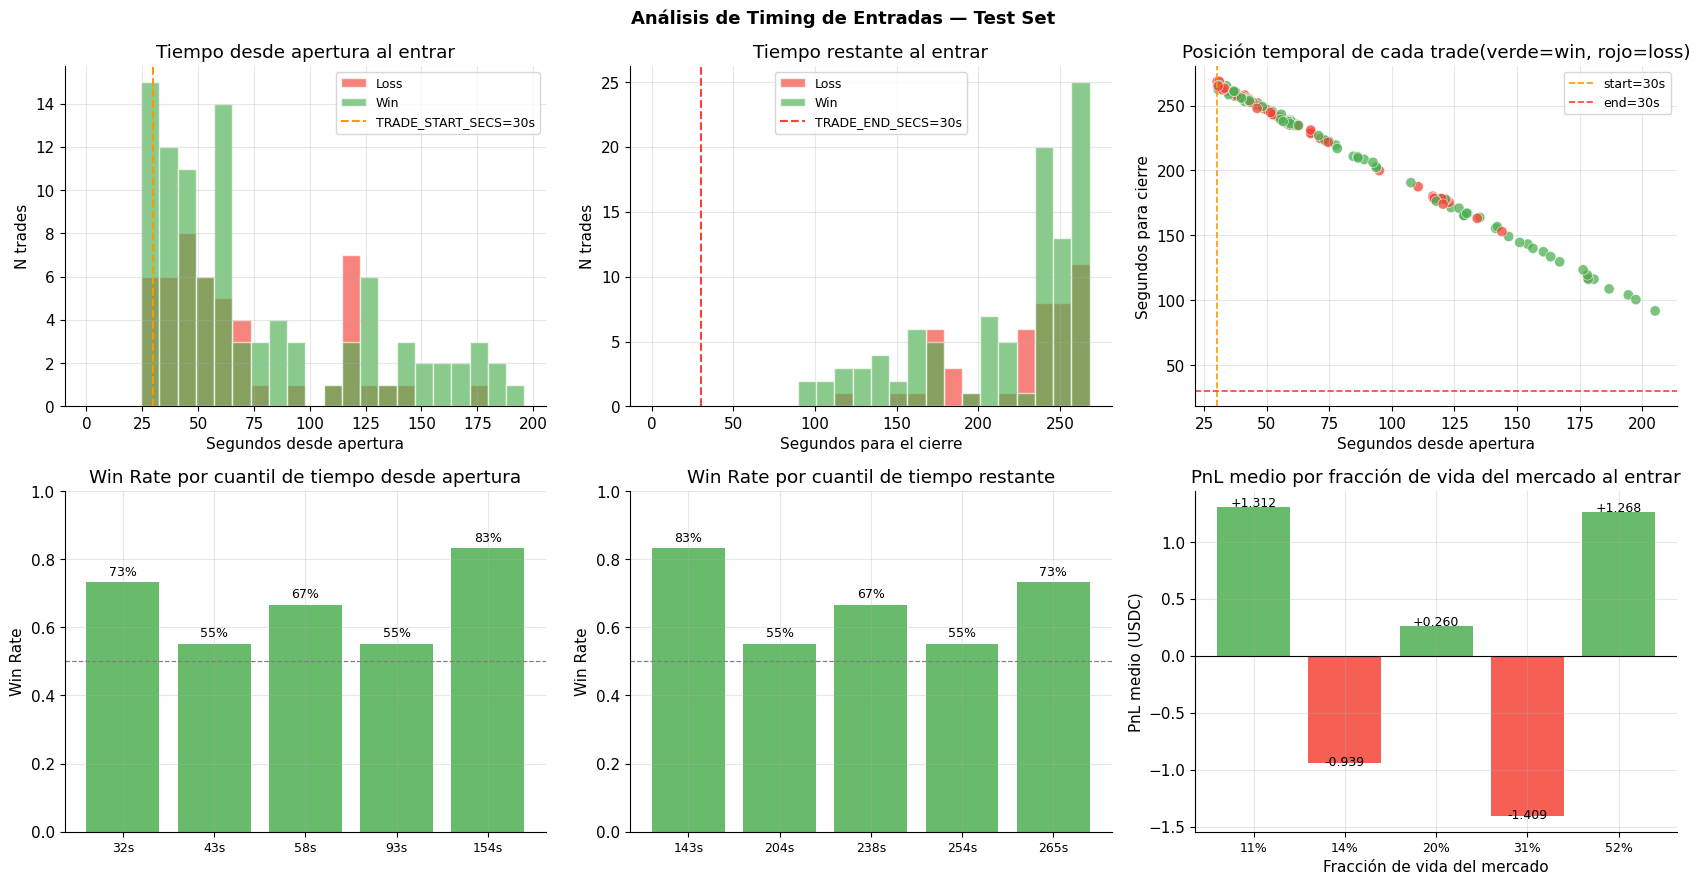


── Resumen de timing (test set) ──
  TRADE_START_SECS activo : 30 s
  TRADE_END_SECS activo   : 30 s
  Tiempo medio de entrada : 75.8 s desde apertura
  Tiempo medio restante   : 220.9 s para cierre
  Duración media mercado  : 296.7 s
  Fracción media de vida  : 25.6%

       seconds_from_open  seconds_to_close  market_duration_s
count              148.0             148.0              148.0
mean                75.8             220.9              296.7
std                 46.6              46.5                1.3
min                 30.3              91.7              293.1
25%                 40.1             179.8              296.0
50%                 58.7             237.8              296.7
75%                116.5             257.2              297.7
max                205.2             268.7              299.8


In [27]:
# =============================================================================
# 9.5. ANÁLISIS DE TIMING DE TRADES
# =============================================================================
if not trade_log.empty and 'seconds_from_open' in trade_log.columns:
    has_timing = trade_log['seconds_from_open'].notna().any()
else:
    has_timing = False

if has_timing:
    tl = trade_log.dropna(subset=['seconds_from_open', 'seconds_to_close']).copy()
    tl['outcome'] = tl['pnl'].apply(lambda x: 'Win' if x > 0 else 'Loss')
    colors_wl = {'Win': '#4CAF50', 'Loss': '#F44336'}

    fig, axes = plt.subplots(2, 3, figsize=(17, 9))
    fig.suptitle('Análisis de Timing de Entradas — Test Set', fontsize=13, fontweight='bold')

    # ── A. Histograma: segundos desde apertura ───────────────────────────────
    ax = axes[0, 0]
    bins = np.linspace(0, tl['seconds_from_open'].quantile(0.99), 25)
    for outcome, grp in tl.groupby('outcome'):
        ax.hist(grp['seconds_from_open'], bins=bins, alpha=0.65,
                label=outcome, color=colors_wl[outcome], edgecolor='white')
    ax.axvline(CFG['TRADE_START_SECS'], ls='--', lw=1.5, color='#FF9800',
               label=f"TRADE_START_SECS={CFG['TRADE_START_SECS']}s")
    ax.set_title('Tiempo desde apertura al entrar')
    ax.set_xlabel('Segundos desde apertura'); ax.set_ylabel('N trades')
    ax.legend(fontsize=9)

    # ── B. Histograma: segundos para el cierre ───────────────────────────────
    ax = axes[0, 1]
    bins2 = np.linspace(0, tl['seconds_to_close'].quantile(0.99), 25)
    for outcome, grp in tl.groupby('outcome'):
        ax.hist(grp['seconds_to_close'], bins=bins2, alpha=0.65,
                label=outcome, color=colors_wl[outcome], edgecolor='white')
    ax.axvline(CFG['TRADE_END_SECS'], ls='--', lw=1.5, color='#F44336',
               label=f"TRADE_END_SECS={CFG['TRADE_END_SECS']}s")
    ax.set_title('Tiempo restante al entrar')
    ax.set_xlabel('Segundos para el cierre'); ax.set_ylabel('N trades')
    ax.legend(fontsize=9)

    # ── C. Scatter: tiempo_desde_apertura vs tiempo_para_cierre, coloreado por PnL
    ax = axes[0, 2]
    c_arr = ['#4CAF50' if p > 0 else '#F44336' for p in tl['pnl']]
    sc = ax.scatter(tl['seconds_from_open'], tl['seconds_to_close'],
                    c=c_arr, alpha=0.75, s=55, edgecolors='white', lw=0.5)
    ax.axvline(CFG['TRADE_START_SECS'], ls='--', lw=1.2, color='#FF9800',
               label=f"start={CFG['TRADE_START_SECS']}s")
    ax.axhline(CFG['TRADE_END_SECS'],   ls='--', lw=1.2, color='#F44336',
               label=f"end={CFG['TRADE_END_SECS']}s")
    ax.set_title('Posición temporal de cada trade(verde=win, rojo=loss)')
    ax.set_xlabel('Segundos desde apertura')
    ax.set_ylabel('Segundos para cierre')
    ax.legend(fontsize=9)

    # ── D. Win Rate vs cuantil de seconds_from_open ──────────────────────────
    ax = axes[1, 0]
    tl['_q_open'] = pd.qcut(tl['seconds_from_open'], q=5, labels=False, duplicates='drop')
    grp_open = tl.groupby('_q_open', observed=True)
    wr_open  = grp_open['pnl'].apply(lambda x: (x > 0).mean())
    mid_open = grp_open['seconds_from_open'].mean()
    bars = ax.bar(range(len(wr_open)), wr_open.values, alpha=0.85,
                  color=['#4CAF50' if v >= 0.5 else '#F44336' for v in wr_open.values])
    ax.axhline(0.5, ls='--', color='gray', lw=0.9)
    ax.set_xticks(range(len(wr_open)))
    ax.set_xticklabels([f'{v:.0f}s' for v in mid_open.values], fontsize=9)
    ax.set_title('Win Rate por cuantil de tiempo desde apertura')
    ax.set_ylabel('Win Rate'); ax.set_ylim(0, 1)
    for bar, v in zip(bars, wr_open.values):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.0%}', ha='center', fontsize=9)

    # ── E. Win Rate vs cuantil de seconds_to_close ───────────────────────────
    ax = axes[1, 1]
    tl['_q_close'] = pd.qcut(tl['seconds_to_close'], q=5, labels=False, duplicates='drop')
    grp_close = tl.groupby('_q_close', observed=True)
    wr_close  = grp_close['pnl'].apply(lambda x: (x > 0).mean())
    mid_close = grp_close['seconds_to_close'].mean()
    bars2 = ax.bar(range(len(wr_close)), wr_close.values, alpha=0.85,
                   color=['#4CAF50' if v >= 0.5 else '#F44336' for v in wr_close.values])
    ax.axhline(0.5, ls='--', color='gray', lw=0.9)
    ax.set_xticks(range(len(wr_close)))
    ax.set_xticklabels([f'{v:.0f}s' for v in mid_close.values], fontsize=9)
    ax.set_title('Win Rate por cuantil de tiempo restante')
    ax.set_ylabel('Win Rate'); ax.set_ylim(0, 1)
    for bar, v in zip(bars2, wr_close.values):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.0%}', ha='center', fontsize=9)

    # ── F. PnL medio vs franja temporal (segundos_desde_apertura / duración) ─
    ax = axes[1, 2]
    tl['entry_frac'] = tl['seconds_from_open'] / tl['market_duration_s'].clip(lower=1)
    tl['_q_frac'] = pd.qcut(tl['entry_frac'], q=5, labels=False, duplicates='drop')
    grp_frac = tl.groupby('_q_frac', observed=True)
    pnl_frac = grp_frac['pnl'].mean()
    mid_frac = grp_frac['entry_frac'].mean()
    bars3 = ax.bar(range(len(pnl_frac)), pnl_frac.values, alpha=0.85,
                   color=['#4CAF50' if v > 0 else '#F44336' for v in pnl_frac.values])
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(range(len(pnl_frac)))
    ax.set_xticklabels([f'{v:.0%}' for v in mid_frac.values], fontsize=9)
    ax.set_title('PnL medio por fracción de vida del mercado al entrar')
    ax.set_xlabel('Fracción de vida del mercado'); ax.set_ylabel('PnL medio (USDC)')
    for bar, v in zip(bars3, pnl_frac.values):
        ax.text(bar.get_x()+bar.get_width()/2, v + (0.003 if v >= 0 else -0.02),
                f'{v:+.3f}', ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Tabla resumen de timing
    print("\n── Resumen de timing (test set) ──")
    print(f"  TRADE_START_SECS activo : {CFG['TRADE_START_SECS']} s")
    print(f"  TRADE_END_SECS activo   : {CFG['TRADE_END_SECS']} s")
    print(f"  Tiempo medio de entrada : {tl['seconds_from_open'].mean():.1f} s desde apertura")
    print(f"  Tiempo medio restante   : {tl['seconds_to_close'].mean():.1f} s para cierre")
    print(f"  Duración media mercado  : {tl['market_duration_s'].mean():.1f} s")
    print(f"  Fracción media de vida  : {tl['entry_frac'].mean():.1%}")
    print()
    print(tl[['seconds_from_open','seconds_to_close','market_duration_s']].describe().round(1).to_string())
else:
    print("No hay columnas de timing en trade_log — asegúrate de haber ejecutado la Sección 2b.")


---
## 10 · Gráficos

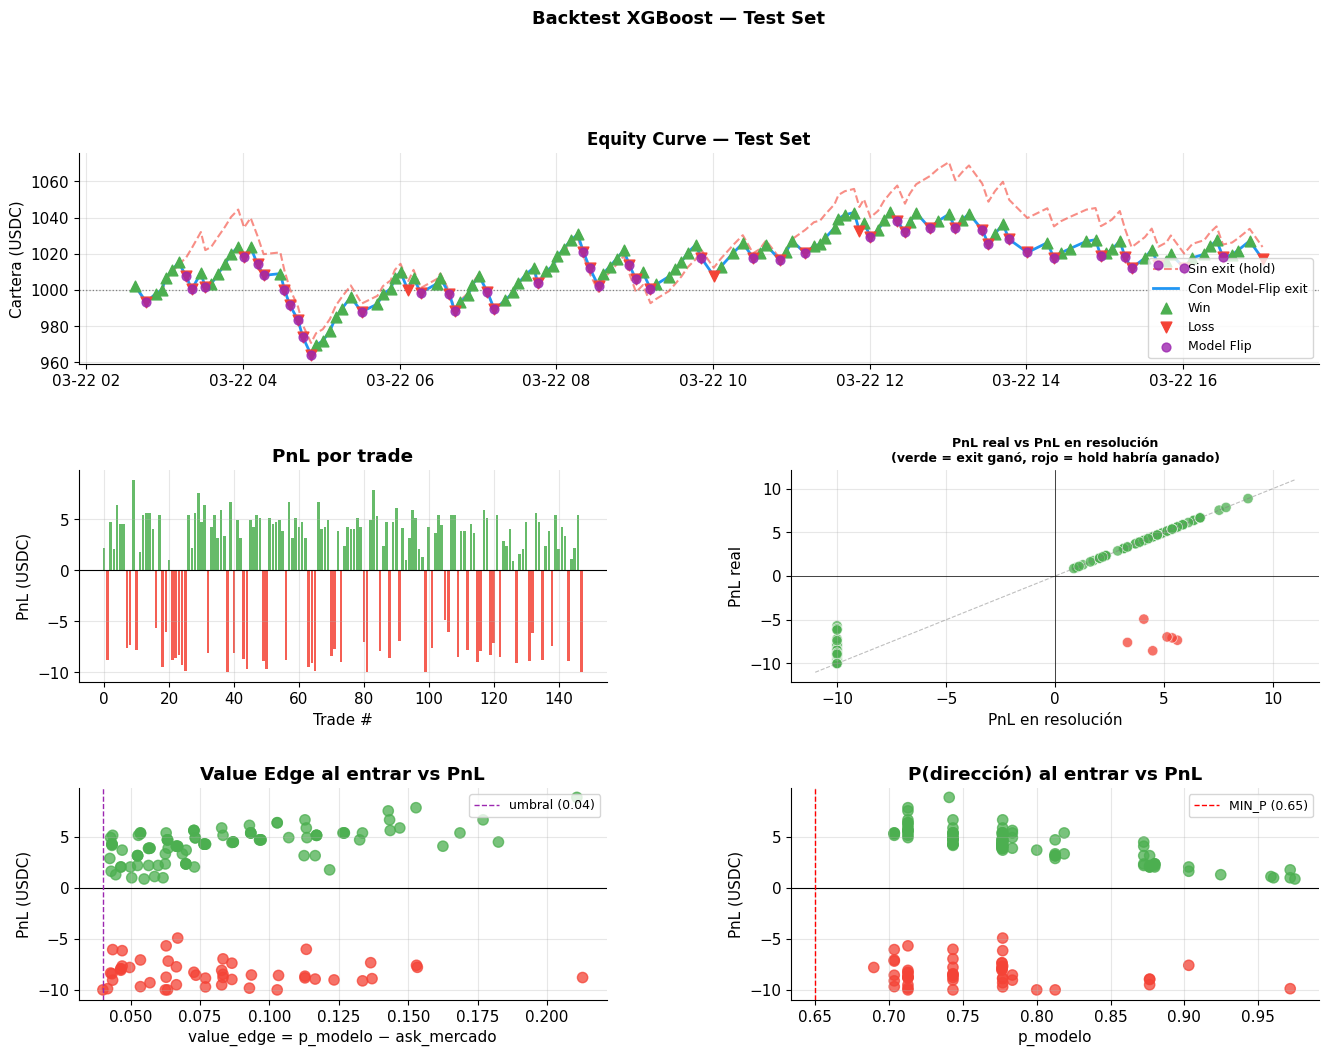

In [28]:
# =============================================================================
# 10. GRÁFICOS
# =============================================================================
if not trade_log.empty:
    fig = plt.figure(figsize=(16, 11))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.50, wspace=0.35)

    # ── 1. Equity curve ──────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[0, :])
    if not trade_log_no.empty:
        ax.plot(equity_no.index, equity_no.values,
                color='#F44336', lw=1.5, alpha=0.6, ls='--', label='Sin exit (hold)')
    ax.plot(equity.index, equity.values, color='#2196F3', lw=2.0, label='Con Model-Flip exit')
    ax.axhline(CFG['INIT_CAPITAL'], ls=':', color='gray', lw=0.9)

    wins_df  = trade_log[trade_log['pnl'] > 0]
    loses_df = trade_log[trade_log['pnl'] <= 0]
    flips_df = trade_log[trade_log['exit_type'] == 'MODEL_FLIP']

    ax.scatter(wins_df['timestamp'],  wins_df['equity'],
               marker='^', s=60, color='#4CAF50', zorder=5, label='Win')
    ax.scatter(loses_df['timestamp'], loses_df['equity'],
               marker='v', s=60, color='#F44336', zorder=5, label='Loss')
    ax.scatter(flips_df['timestamp'], flips_df['equity'],
               marker='o', s=40, color='#9C27B0', zorder=6, alpha=0.8, label='Model Flip')

    ax.set_title('Equity Curve — Test Set', fontsize=12, fontweight='bold')
    ax.set_ylabel('Cartera (USDC)'); ax.legend(fontsize=9)

    # ── 2. PnL por trade ─────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[1, 0])
    colors_bar = ['#4CAF50' if p > 0 else '#F44336' for p in trade_log['pnl']]
    ax.bar(range(len(trade_log)), trade_log['pnl'].values, color=colors_bar, alpha=0.85)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title('PnL por trade', fontweight='bold')
    ax.set_xlabel('Trade #'); ax.set_ylabel('PnL (USDC)')

    # ── 3. Exit: PnL con exit vs PnL en resolución ───────────────────────────
    ax = fig.add_subplot(gs[1, 1])
    c_arr = ['#4CAF50' if p >= r else '#F44336'
             for p, r in zip(trade_log['pnl'], trade_log['pnl_at_resolution'])]
    ax.scatter(trade_log['pnl_at_resolution'], trade_log['pnl'],
               c=c_arr, alpha=0.75, s=55, edgecolors='white', lw=0.5)
    lim = max(abs(trade_log[['pnl','pnl_at_resolution']].values).max() * 1.1, 1)
    ax.plot([-lim, lim], [-lim, lim], '--', color='gray', alpha=0.5, lw=0.8)
    ax.axhline(0, color='black', lw=0.5); ax.axvline(0, color='black', lw=0.5)
    ax.set_title('PnL real vs PnL en resolución\n(verde = exit ganó, rojo = hold habría ganado)',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('PnL en resolución'); ax.set_ylabel('PnL real')

    # ── 4. VALUE_EDGE de entrada vs PnL ──────────────────────────────────────
    ax = fig.add_subplot(gs[2, 0])
    c_arr2 = ['#4CAF50' if p > 0 else '#F44336' for p in trade_log['pnl']]
    ax.scatter(trade_log['value_edge_entry'], trade_log['pnl'],
               c=c_arr2, alpha=0.75, s=55)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(CFG['VALUE_EDGE'], ls='--', color='#9C27B0', lw=1, label=f"umbral ({CFG['VALUE_EDGE']})")
    ax.set_title('Value Edge al entrar vs PnL', fontweight='bold')
    ax.set_xlabel('value_edge = p_modelo − ask_mercado'); ax.set_ylabel('PnL (USDC)')
    ax.legend(fontsize=9)

    # ── 5. P(dirección) vs PnL ───────────────────────────────────────────────
    ax = fig.add_subplot(gs[2, 1])
    ax.scatter(trade_log['p_entry'], trade_log['pnl'], c=c_arr2, alpha=0.75, s=55)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(CFG['MIN_P'], ls='--', color='red', lw=1, label=f"MIN_P ({CFG['MIN_P']})")
    ax.set_title('P(dirección) al entrar vs PnL', fontweight='bold')
    ax.set_xlabel('p_modelo'); ax.set_ylabel('PnL (USDC)')
    ax.legend(fontsize=9)

    plt.suptitle('Backtest XGBoost — Test Set', fontsize=13, fontweight='bold', y=1.01)
    plt.show()

---
## 11 · Sensibilidad de Parámetros

Resultados del barrido de parámetros (test set):
  VE  MIN_P  Flip   N    WR    PnL    PF
0.10   0.60  0.35 104 0.596  51.97 1.194
0.10   0.60  0.30 104 0.596  51.97 1.194
0.05   0.60  0.35 149 0.597  45.11 1.119
0.10   0.63  0.30 102 0.598  43.42 1.166
0.10   0.63  0.35 102 0.598  43.42 1.166
0.10   0.70  0.25  95 0.632  42.93 1.177
0.10   0.70  0.30  95 0.621  41.66 1.175
0.10   0.70  0.35  95 0.621  41.66 1.175
0.10   0.60  0.25 104 0.606  40.38 1.142
0.05   0.60  0.30 149 0.597  39.93 1.104
0.10   0.65  0.25  96 0.625  36.20 1.145
0.10   0.68  0.25  96 0.625  36.20 1.145
0.10   0.65  0.35  96 0.615  35.50 1.145
0.10   0.65  0.30  96 0.615  35.50 1.145
0.10   0.68  0.35  96 0.615  35.50 1.145
0.10   0.68  0.30  96 0.615  35.50 1.145
0.10   0.63  0.25 102 0.608  33.64 1.121
0.05   0.63  0.35 147 0.605  31.66 1.085
0.05   0.63  0.30 147 0.605  30.75 1.082
0.05   0.68  0.35 144 0.618  26.57 1.074
0.05   0.65  0.35 144 0.618  26.57 1.074
0.05   0.60  0.25 149 0.604  26.00 1.064
0.05   0

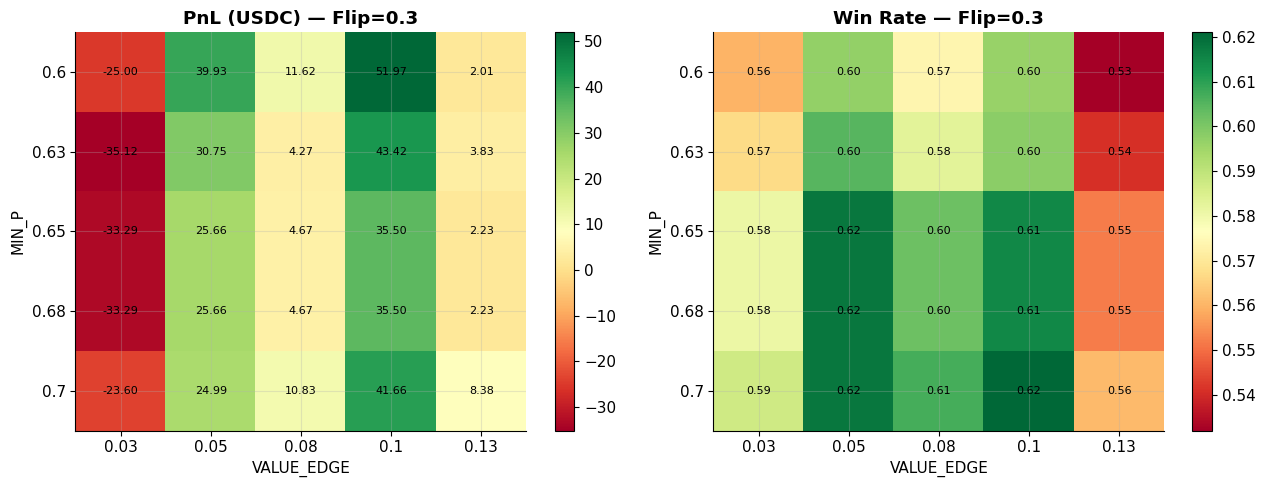


Sensibilidad de timing (VE=0.1, MIN_P=0.6, Flip=0.3):
 T_START  T_END   N    WR   PnL    PF
       0      0 104 0.596 53.65 1.201
       0     10 104 0.596 53.65 1.201
       0     20 104 0.596 53.65 1.201
       0     40 104 0.596 53.65 1.201
      15      0 104 0.596 53.65 1.201
      15     10 104 0.596 53.65 1.201
      15     20 104 0.596 53.65 1.201
      15     40 104 0.596 53.65 1.201
      30      0 104 0.596 51.97 1.194
      30     10 104 0.596 51.97 1.194
      30     20 104 0.596 51.97 1.194
      30     40 104 0.596 51.97 1.194
      60      0  86 0.581 -3.10 0.987
      60     10  86 0.581 -3.10 0.987
      60     20  86 0.581 -3.10 0.987
      60     40  86 0.581 -3.10 0.987

Mejor combinación de timing:  T_START=0.0s  T_END=0.0s
  N=104.0  WR=59.6%  PnL=+53.65  PF=1.201


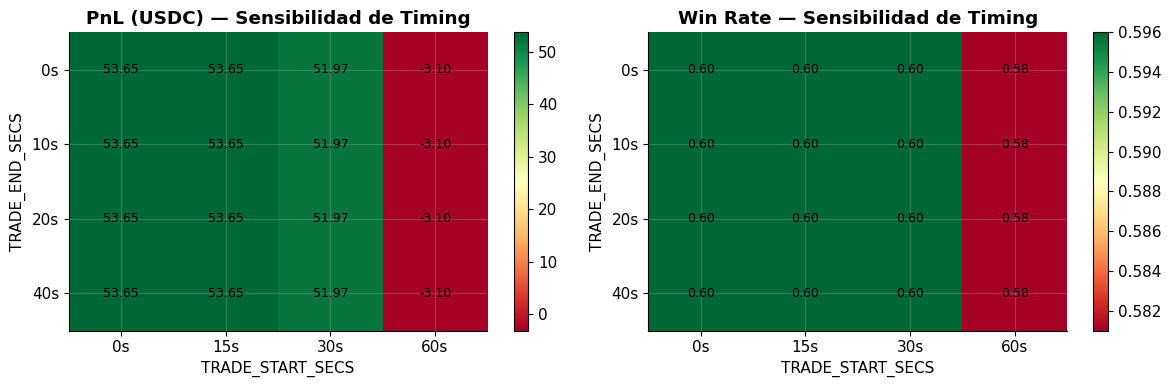

sensitivity_timing.csv guardado.


In [29]:
# =============================================================================
# 11. SENSIBILIDAD: VALUE_EDGE × MIN_P × FLIP_THRESH
# =============================================================================
ve_grid     = [0.03, 0.05, 0.08, 0.10, 0.13]
mp_grid     = [0.60, 0.63, 0.65, 0.68, 0.70]
flip_grid   = [0.25, 0.30, 0.35]

# ── Barrido de parámetros de timing ──────────────────────────────────────
# Se barre independientemente del barrido principal (producto cartesiano
# sería demasiado costoso). Mantenemos los mejores VE/MIN_P/Flip fijos.
t_start_grid = [0, 15, 30, 60]    # TRADE_START_SECS
t_end_grid   = [0, 10, 20, 40]    # TRADE_END_SECS

sens_rows = []
for ve in ve_grid:
    for mp in mp_grid:
        for flip in flip_grid:
            cfg_s = {**CFG, 'VALUE_EDGE': ve, 'MIN_P': mp, 'FLIP_THRESH': flip}
            tl, eq_s = run_backtest(test_fe, cfg_s)
            if tl.empty:
                sens_rows.append({'VE': ve, 'MIN_P': mp, 'Flip': flip,
                                  'N': 0, 'WR': np.nan, 'PnL': np.nan, 'PF': np.nan})
                continue
            gp = tl[tl['pnl'] > 0]['pnl'].sum()
            gl = tl[tl['pnl'] < 0]['pnl'].abs().sum()
            sens_rows.append({
                'VE'   : ve, 'MIN_P': mp, 'Flip': flip,
                'N'    : len(tl),
                'WR'   : round((tl['pnl']>0).mean(), 3),
                'PnL'  : round(tl['pnl'].sum(),       2),
                'PF'   : round(gp / (gl + 1e-9),       3),
            })

df_sens = pd.DataFrame(sens_rows)
print("Resultados del barrido de parámetros (test set):")
print(df_sens.sort_values('PnL', ascending=False).to_string(index=False))

best_row = df_sens.loc[df_sens['PnL'].idxmax()]
print(f"\nMejor combinación (PnL):  VE={best_row.VE}  MIN_P={best_row.MIN_P}  Flip={best_row.Flip}")
print(f"  N={best_row.N}  WR={best_row.WR:.1%}  PnL={best_row.PnL:+.2f}  PF={best_row.PF:.3f}")

best_flip = df_sens.loc[df_sens['PnL'].idxmax(), 'Flip']
sub = df_sens[df_sens['Flip'] == best_flip]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, title, cmap in [
    (axes[0], 'PnL', f'PnL (USDC) — Flip={best_flip}', 'RdYlGn'),
    (axes[1], 'WR',  f'Win Rate — Flip={best_flip}',    'RdYlGn'),
]:
    pivot = sub.pivot(index='MIN_P', columns='VE', values=col)
    im = ax.imshow(pivot.values.astype(float), cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
    ax.set_xlabel('VALUE_EDGE'); ax.set_ylabel('MIN_P')
    ax.set_title(title, fontweight='bold')
    plt.colorbar(im, ax=ax)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if not np.isnan(float(v)):
                ax.text(j, i, f'{float(v):.2f}', ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()


# =============================================================================
# 11b. SENSIBILIDAD: TRADE_START_SECS × TRADE_END_SECS
# =============================================================================
best_ve   = best_row.VE
best_mp   = best_row['MIN_P']
best_flip = best_row.Flip

timing_rows = []
for ts in t_start_grid:
    for te in t_end_grid:
        cfg_t = {**CFG, 'VALUE_EDGE': best_ve, 'MIN_P': best_mp,
                 'FLIP_THRESH': best_flip,
                 'TRADE_START_SECS': ts, 'TRADE_END_SECS': te}
        tl_t, _ = run_backtest(test_fe, cfg_t)
        if tl_t.empty:
            timing_rows.append({'T_START': ts, 'T_END': te,
                                 'N': 0, 'WR': np.nan, 'PnL': np.nan, 'PF': np.nan})
            continue
        gp_t = tl_t[tl_t['pnl'] > 0]['pnl'].sum()
        gl_t = tl_t[tl_t['pnl'] < 0]['pnl'].abs().sum()
        timing_rows.append({
            'T_START': ts, 'T_END': te,
            'N'  : len(tl_t),
            'WR' : round((tl_t['pnl'] > 0).mean(), 3),
            'PnL': round(tl_t['pnl'].sum(), 2),
            'PF' : round(gp_t / (gl_t + 1e-9), 3),
        })

df_timing_sens = pd.DataFrame(timing_rows)
print(f"\nSensibilidad de timing (VE={best_ve}, MIN_P={best_mp}, Flip={best_flip}):")
print(df_timing_sens.sort_values('PnL', ascending=False).to_string(index=False))

best_t = df_timing_sens.loc[df_timing_sens['PnL'].idxmax()]
print(f"\nMejor combinación de timing:  T_START={best_t.T_START}s  T_END={best_t.T_END}s")
print(f"  N={best_t.N}  WR={best_t.WR:.1%}  PnL={best_t.PnL:+.2f}  PF={best_t.PF:.3f}")

# Heatmap de timing
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in [
    (axes[0], 'PnL', 'PnL (USDC)'),
    (axes[1], 'WR',  'Win Rate'),
]:
    pivot = df_timing_sens.pivot(index='T_END', columns='T_START', values=col)
    im = ax.imshow(pivot.values.astype(float), cmap='RdYlGn', aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'{v}s' for v in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{v}s' for v in pivot.index])
    ax.set_xlabel('TRADE_START_SECS'); ax.set_ylabel('TRADE_END_SECS')
    ax.set_title(f'{title} — Sensibilidad de Timing', fontweight='bold')
    plt.colorbar(im, ax=ax)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if not np.isnan(float(v)):
                ax.text(j, i, f'{float(v):.2f}', ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()

df_timing_sens.to_csv('sensitivity_timing.csv', index=False)
print("sensitivity_timing.csv guardado.")


---
## 13 · Resumen y Guía de Ajuste

In [30]:
# =============================================================================
# 13. RESUMEN FINAL
# =============================================================================
D = '=' * 58
print(D)
print('  RESUMEN — Polymarket BTC XGBoost v3')
print(D)
print(f"  Modelo      : {'XGBoost' if USE_XGB else 'HistGBT (sklearn)'}")
print(f"  Features    : {len(FEATURES)}")
print(f"  Test AUC    : {roc_auc_score(y_te, MODEL.predict_proba(X_te)[:,1]):.4f}")
print(f"  Filtros     : MIN_P>={CFG['MIN_P']}  VALUE_EDGE>={CFG['VALUE_EDGE']}")
print(f"  Timing      : start>={CFG['TRADE_START_SECS']}s  end>{CFG['TRADE_END_SECS']}s")
print(f"  Exit        : Model-Flip < {CFG['FLIP_THRESH']} (sin stop-loss por precio)")

if not trade_log.empty and not trade_log_no.empty:
    print(f"\n  {'':18} {'CON exit':>12} {'SIN exit':>12}")
    print(f"  {'-'*44}")
    print(f"  {'N trades':<18} {len(trade_log):>12} {len(trade_log_no):>12}")
    print(f"  {'Win Rate':<18} {(trade_log['pnl']>0).mean():>11.1%} {(trade_log_no['pnl']>0).mean():>11.1%}")
    print(f"  {'PnL Total':<18} {trade_log['pnl'].sum():>+11.2f} {trade_log_no['pnl'].sum():>+11.2f}")
    eq=equity.values; rm=np.maximum.accumulate(eq); mdd=((eq-rm)/rm).min()
    eq2=equity_no.values; rm2=np.maximum.accumulate(eq2); mdd2=((eq2-rm2)/rm2).min()
    print(f"  {'Max Drawdown':<18} {mdd:>11.2%} {mdd2:>11.2%}")
print(D)

print("""
GUÍA DE AJUSTE DE PARÁMETROS:

  VALUE_EDGE  (más importante):
    El filtro que más impacta en la calidad de las entradas.
    • 0.20 — más trades, WR moderada (~55–60%)
    • 0.25 — balance óptimo (configuración actual)
    • 0.30 — menos trades, WR más alta, menor diversificación
    Subir si el mercado es eficiente; bajar si hay más ineficiencias.

  MIN_P:
    • 0.60 — incluye señales moderadas del modelo
    • 0.65 — balance entre cantidad y calidad
    • 0.70 — solo señales de alta convicción
    Subir si se observan muchas entradas equivocadas.

  FLIP_THRESH:
    • 0.30 — exit solo en casos extremos de cambio de señal
    • 0.35 — balance (configuración actual)
    • 0.40 — más agresivo, sale antes ante incertidumbre
    Bajar si el exit está cortando posiciones que recuperan.

  NOTA: VALUE_EDGE es el parámetro más robusto porque su lógica es
  fundamental — entrar solo cuando el modelo sabe algo que el mercado
  no ha descontado. Los demás parámetros son filtros de calidad adicionales.
""")

  RESUMEN — Polymarket BTC XGBoost v3
  Modelo      : XGBoost
  Features    : 19
  Test AUC    : 0.8047
  Filtros     : MIN_P>=0.65  VALUE_EDGE>=0.04
  Timing      : start>=30s  end>30s
  Exit        : Model-Flip < 0.15 (sin stop-loss por precio)

                         CON exit     SIN exit
  --------------------------------------------
  N trades                    148          148
  Win Rate                 66.9%       70.9%
  PnL Total               +17.12      +23.79
  Max Drawdown            -5.83%      -7.06%

GUÍA DE AJUSTE DE PARÁMETROS:

  VALUE_EDGE  (más importante):
    El filtro que más impacta en la calidad de las entradas.
    • 0.20 — más trades, WR moderada (~55–60%)
    • 0.25 — balance óptimo (configuración actual)
    • 0.30 — menos trades, WR más alta, menor diversificación
    Subir si el mercado es eficiente; bajar si hay más ineficiencias.

  MIN_P:
    • 0.60 — incluye señales moderadas del modelo
    • 0.65 — balance entre cantidad y calidad
    • 0.70 — so